In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Promoter-level chec-seq binding signal (sumprom) for Human TFs
chec_sumprom_glob = "sumproms/*.gz"

# Promoter-level chec-seq signal (sumprom) for yeast TFs (see manuscript)
native_tf_sumprom_pattern = "../Yeast_Native_TF_outfiles/results/sumproms/*.gz"

## Imports

In [3]:
import glob

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy.stats import zscore

## Family metadata

In [4]:
FOXK1_WT = ["FOXP3", "FOXA2", "FOXF1", "FOXL1", "FOXL2", "FOXJ2", "FOXO3", "FOXP1", "FOXP2"]
GABPA_WT = ["ELF1", "ELF2", "ERF1", "ELK1", "ELK4", "ERG", "FLI1"]
SOX10_WT = ["SOX15", "SOX17", "SOX7", "SOX11", "SOX4", "SOX6", "SOX30", "SOX9", "SOX13", "SOX5"]
HXD10_WT = ["CDX2", "HOXA11", "HOXC10", "HOXD9", "HOXA10", "HOXC9", "HOXA9", "HOXB9", "CDX4", "HOXC13"]
GATA1_WT = ["GATA3", "GATA6", "GATA4", "GATA2", "GATA5"]
BATF3_WT = ["ATF4", "FOS", "CREB5", "ATF1", "CREB1", "ATF2"]
HEY1_WT = ["MNT", "MLXIPL", "MLX", "MXD4"]
NFAC4_WT = ["NFATC4", "NFATC3"]
TF2LY_WT = ["TGIF2LX", "TGIF2LY", "TGIF1", "TGIF2"]
PO3F2_WT = ["POU2F3", "POU3F4", "POU3F1"]

dbd_fam_dict = {
    "FOXK1": FOXK1_WT,
    "GABPA": GABPA_WT,
    "SOX10": SOX10_WT,
    "HXD10": HXD10_WT,
    "GATA1": GATA1_WT,
    "BATF3": BATF3_WT,
    "HEY1": HEY1_WT,
    "NFAC4": NFAC4_WT,
    "TF2LY": TF2LY_WT,
    "PO3F2": PO3F2_WT,
}

family_name = {
    "BATF3": "bZIP",
    "FOXK1": "Forkhead",
    "GABPA": "ETS",
    "HEY1": "bHLH",
    "HXD10": "Homeodomain\nHOX",
    "NFAC4": "Rel",
    "SOX10": "SOX",
    "TF2LY": "Homeodomain\nTALE-Type",
    "PO3F2": "Homeodomain\nPOU",
    "GATA1": "GATA",
}

exists_in_yeast = {
    "FOXK1": "yes",
    "GABPA": "no",
    "SOX10": "no",
    "HXD10": "no",
    "GATA1": "yes",
    "BATF3": "yes",
    "HEY1": "yes",
    "NFAC4": "no",
    "TF2LY": "no",
    "PO3F2": "no",
}

fam_plot_order = ["FOXK1", "BATF3", "GATA1", "HEY1", "GABPA", "NFAC4", "TF2LY", "PO3F2", "PO3F2", "HXD10", "SOX10"]

## Data loading

In [5]:
corr_cutoff = 0.895

# Keep only reproducible samples within each TF group
def filter_reproducible(sumprom_all, cutoff):
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]

    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

# Load human TF promoter scores and average replicates
sumprom_chec_files = glob.glob(chec_sumprom_glob)
sumprom_all = pd.concat([pd.read_parquet(path) for path in sumprom_chec_files], axis=1)
sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit("_", n=2).str[0]
cols_to_keep = set(sum(dbd_fam_dict.values(), []))

sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom = sumprom.loc[:, sumprom.columns.intersection(cols_to_keep)]
sumprom_z = sumprom.apply(zscore)

# Load yeast TF promoter scores and z-score each TF across promoters
native_tf_sumprom_files = glob.glob(native_tf_sumprom_pattern)
native_tf_sumprom = pd.concat([pd.read_parquet(path) for path in native_tf_sumprom_files], axis=1)
non_transcription_factors = ["Nfi1", "Itc1", "Gal11", "Nhp6A", "Spt20", "Nhp6B", "Abf2", "Tog1", "Siz1", "Cyc8", "Mss11"]
native_tf_sumprom = native_tf_sumprom.drop(columns=non_transcription_factors)
native_tf_sumprom_z = native_tf_sumprom.apply(zscore)

## Helper functions

In [6]:
# Define yeast-bound promoters using the original thresholding rule
def yeast_bound_mask(native_df, z, mode="any", yeast_tfs_required=3):
    above = native_df > z
    if mode == "any":
        return above.any(axis=1)
    if mode == "absolute_number":
        return above.sum(axis=1) >= yeast_tfs_required
    raise ValueError('mode must be "any" or "absolute_number"')

# Build the TF ordering table used for the violin plot
def family_sort_table(tfs, obs_pct, n_bound, null_pcts, dbd_fam_dict, fam_plot_order):
    tf_to_fam = {tf: fam for fam, tflist in dbd_fam_dict.items() for tf in tflist}
    fam_rank = {fam: i for i, fam in enumerate(fam_plot_order)}
    other_rank = len(fam_plot_order) + 1

    res = pd.DataFrame({
        "tf": tfs,
        "fam": [tf_to_fam.get(tf, "Other") for tf in tfs],
        "fam_rank": [fam_rank.get(tf_to_fam.get(tf, "Other"), other_rank) for tf in tfs],
        "obs_pct": obs_pct,
        "n": n_bound,
        "null": null_pcts,
    })
    return res.sort_values(["fam_rank", "fam", "obs_pct"], ascending=[True, True, False]).reset_index(drop=True)

# Add extra space between TF families in the plot
def spaced_positions(fams, tf_spacing=1.1, fam_gap=1.0):
    xpos, seps, x = [], [], 0.0
    prev = None
    for fam in fams:
        if prev is not None and fam != prev:
            seps.append(x - 0.5 + fam_gap / 2)
            x += fam_gap
        xpos.append(x)
        x += tf_spacing
        prev = fam
    return np.array(xpos), seps

## Compute plot inputs

In [7]:
z_cutoff = 3
n_perm = 1000

# Define yeast binding as: promoter is bound if ≥ yeast_tfs_required TFs pass the cutoff
yeast_tfs_required = 3

between_tf_spacing = 1.1
between_fam_extra_gap = 1.0

# Align yeast data to the same promoter index as the human data
native = native_tf_sumprom_z.reindex(sumprom_z.index)

# Boolean mask: promoter is yeast-bound if enough yeast TFs exceed the cutoff
yeast_bound = (native > z_cutoff).sum(axis=1) >= yeast_tfs_required

all_idx = yeast_bound.index.to_numpy()
tfs = list(sumprom_z.columns)

obs_pct = []     # observed % yeast-bound per TF
n_bound = []     # number of promoters bound by each TF
null_pcts = []   # null distributions per TF

# For each human TF:
# compare observed yeast-binding rate to random promoter sets of the same size
for tf in tfs:
    human_bound = sumprom_z[tf] > z_cutoff
    n = int(human_bound.sum())
    n_bound.append(n)

    if n == 0:
        obs_pct.append(np.nan)
        null_pcts.append(np.array([np.nan]))
        continue

    # observed fraction of yeast-bound promoters among TF-bound promoters
    obs = 100.0 * yeast_bound[human_bound].mean()
    obs_pct.append(obs)

    # null: randomly sample promoters and compute the same fraction
    draws = []
    for _ in range(n_perm):
        sampled = np.random.choice(all_idx, size=n, replace=False)
        draws.append(100.0 * yeast_bound.loc[sampled].mean())
    null_pcts.append(np.asarray(draws))

# Order TFs by family and observed percentage (same as in main plot)
res = family_sort_table(tfs, obs_pct, n_bound, null_pcts, dbd_fam_dict, fam_plot_order)

cols_ordered = res["tf"].tolist()
obs_ordered = res["obs_pct"].to_numpy()
n_ordered = res["n"].to_numpy()
null_ordered = res["null"].tolist()
fam_ordered = res["fam"].tolist()

# Compute y positions and family separators for plotting
xpos, separators = spaced_positions(
    fam_ordered,
    tf_spacing=between_tf_spacing,
    fam_gap=between_fam_extra_gap,
)

## Plotting

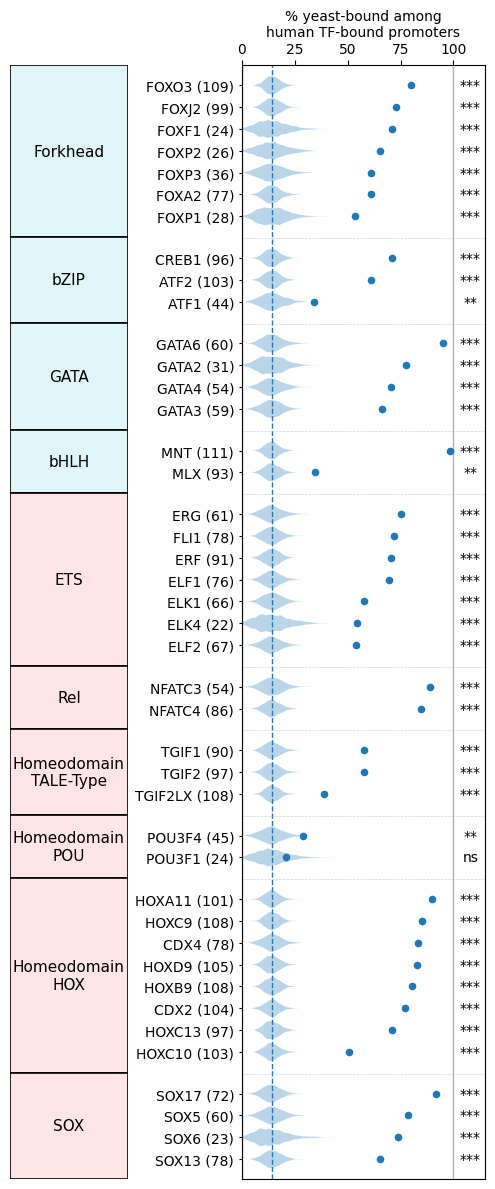

In [8]:
# Plot the rotated violin summary with significance stars and the family strip
fig, ax = plt.subplots(figsize=(3.8, 12))

ax.axvline(100, color="0.7", linewidth=1, zorder=0)
ax.axvline(0, color="black", linewidth=0.8, zorder=0)

ax.violinplot(
    null_ordered,
    positions=xpos,
    widths=0.9,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    vert=False,
)

ax.scatter(obs_ordered, xpos, s=20, zorder=3)

baseline = 100.0 * yeast_bound.mean()
ax.axvline(baseline, linestyle="--", linewidth=1)

for sy in separators:
    ax.axhline(sy, linestyle="--", linewidth=0.5, color="0.7", alpha=0.6)

yticklabels = [f"{"ERF" if tf == "ERF1" else tf} ({n})" for tf, n in zip(cols_ordered, n_ordered)]
ax.set_yticks(xpos)
ax.set_yticklabels(yticklabels)
ax.tick_params(axis="y", length=2)

ax.set_xlabel("% yeast-bound among\nhuman TF-bound promoters")
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

ax.set_xlim(0, 115)

x_star = 108
for y, obs, null, n in zip(xpos, obs_ordered, null_ordered, n_ordered):
    if np.isnan(obs) or null is None or len(null) == 0 or np.all(np.isnan(null)):
        continue

    null = np.asarray(null)
    null = null[~np.isnan(null)]
    if null.size == 0:
        continue

    p = (np.sum(null >= obs) + 1) / (null.size + 1)

    if p <= 0.001:
        s = "***"
    elif p <= 0.01:
        s = "**"
    elif p <= 0.05:
        s = "*"
    else:
        s = "ns"

    ax.text(x_star, y, s, va="center", ha="center", fontsize=10)

plt.margins(y=0.01)
ax.invert_yaxis()

plt.tight_layout()
fig.canvas.draw()

yeast_no_color, yeast_yes_color = "#FFE5E5", "#DFF5F7"

blocks = []
start = 0
for i in range(1, len(fam_ordered) + 1):
    if i == len(fam_ordered) or fam_ordered[i] != fam_ordered[i - 1]:
        blocks.append((fam_ordered[start], start, i - 1))
        start = i

pos = ax.get_position()
strip_w = 0.31
pad = 0.3

ax_fam = fig.add_axes([pos.x0 - pad - strip_w, pos.y0, strip_w, pos.height], sharey=ax)
ax_fam.set_xlim(0, 1)
ax_fam.axis("off")

n = len(xpos)
edges = np.empty(n + 1, dtype=float)
edges[1:-1] = 0.5 * (xpos[:-1] + xpos[1:])

y0_lim, y1_lim = ax.get_ylim()
ymin_lim, ymax_lim = min(y0_lim, y1_lim), max(y0_lim, y1_lim)
edges[0] = ymin_lim
edges[-1] = ymax_lim

for fam, s0, e0 in blocks:
    y0 = edges[s0]
    y1 = edges[e0 + 1]
    y_lo, y_hi = min(y0, y1), max(y0, y1)

    flag = str(exists_in_yeast.get(fam, "no")).strip().lower()
    fc = yeast_yes_color if flag == "yes" else yeast_no_color

    ax_fam.add_patch(
        mpatches.Rectangle((0, y_lo), 1, y_hi - y_lo, fc=fc, ec="black", lw=1.2)
    )

    label = family_name.get(fam, fam)
    yc = 0.5 * (y_lo + y_hi)
    ax_fam.text(0.5, yc, label, ha="center", va="center", fontsize=11)

plt.show()